# usage examples for module: met radar 

### 1.1 test read -- cinrad

d:\Seafile\Share\notebooks\1.utilities\modules\tool\plot.py:86: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im=plt.pcolormesh(xx,yy,cc,cmap=self.field_cmap[field][0],


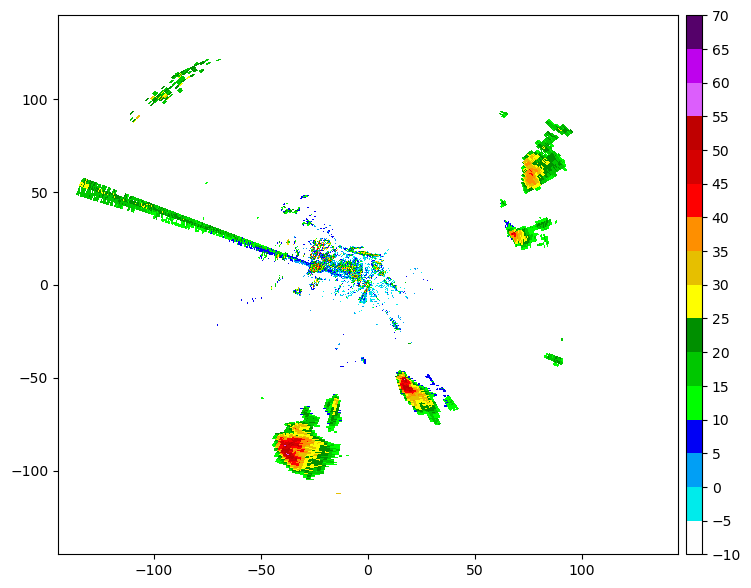

In [4]:
from read.cinrad_dp import read_cinrad_dp
import os

indir='D:/Seafile/Share/notebooks/20230523DisplayGUI/dual_pol_radar_plot/testdata/'
fname='NJU.20220729.105032.AR2.bz2'
inpath=os.path.join(indir,fname)
radar=read_cinrad_dp(inpath)

swp,field_name,field=0,'reflectivity','REF'
field_data=radar.get_field(swp,field_name)

x,y,z=radar.get_gate_x_y_z(swp)
xx,yy,cc=x/1000,y/1000,field_data

from tool.plot import plot
radarplot=plot(xx,yy,cc,'REF')
radarplot.ppi()

Reading: D:/Seafile/Share/notebooks/20230523DisplayGUI/dual_pol_radar_plot/testdata/NJU.20220729.105032.AR2.bz2
First radial num: 0 
Last radial num: 5429
All info & data in dict: "info" and "rec"



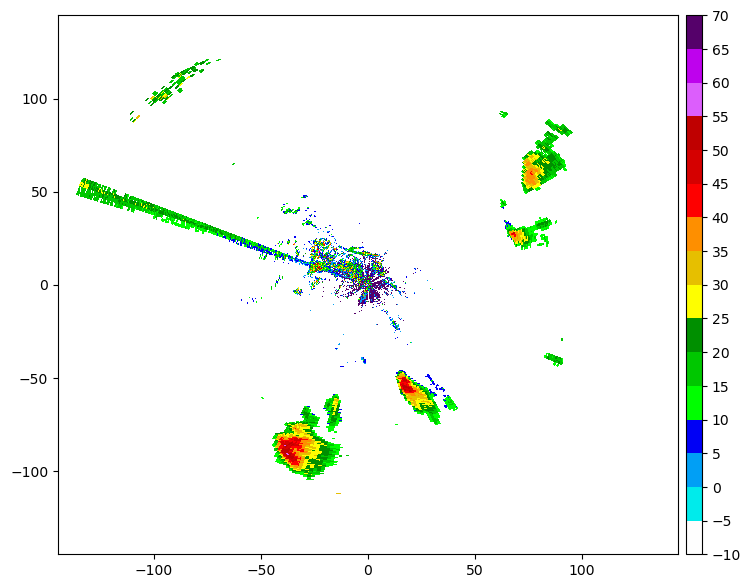

In [62]:
from read.cinrad import cinrad
import os

indir='D:/Seafile/Share/notebooks/20230523DisplayGUI/dual_pol_radar_plot/testdata/'
fname='NJU.20220729.105032.AR2.bz2'
inpath=os.path.join(indir,fname)

field,nswp='REF',0

radar=cinrad(inpath)
ran,azi,ele,field_data=radar.get_cut(field,nswp)
field_data.fill_value=-9999
xx,yy,cc=radar.spherical2cartesian(ran,azi,ele,field_data)
    
from tool.plot import plot
outdir='./'
# savepath=outdir+str(swp+1)+field+'.png'
radarplot=plot(xx,yy,cc,'REF')
radarplot.ppi()

qc

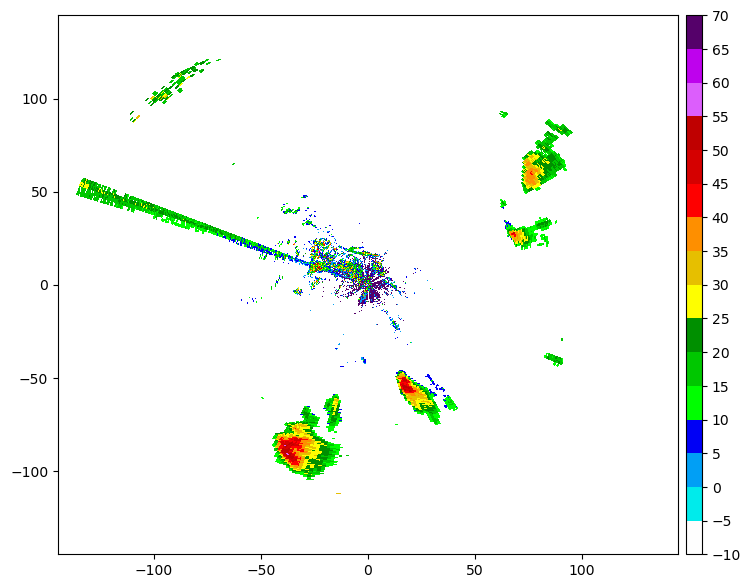

In [61]:
import numpy as np
field_data_qc=field_data
field_data_qc.fill_value=-9999
[nx,ny]=field_data_qc.shape
n=2
for i in range(nx)[n-1:1-n]:
    for j in range(ny)[n-1:1-n]:
        if field_data_qc.mask[i,j]==False:
            tmp=field_data_qc[i-n+1:i+n,j-n+1:j+n]
            if np.max(tmp)-np.min(tmp)>1:
                # print('1')
                field_data_qc.mask[i,j]==True
            # elif not(tmp.mask[0,1] and tmp.mask[1,0] and tmp.mask[1,2] and tmp.mask[2,1]):
                # field_data_qc.mask[i,j]==True
            elif np.sum(~tmp.mask)<len(tmp)/3:
                field_data_qc.mask[i,j]==True

xx,yy,cc=radar.spherical2cartesian(ran,azi,ele,field_data_qc)
from tool.plot import plot
outdir='./'
# savepath=outdir+str(swp+1)+field+'.png'
radarplot=plot(xx,yy,cc,'REF')
radarplot.ppi()

get data

In [ ]:
def get_data(radar):
    from read.cinrad import data_type
    import numpy as np
    nrays=len(radar.rec['data'])
    nswps=radar.info['task']['cut_number']
    # data={'elevation':[],'azimuth':[]}
    rays_each_swp=[[] for _ in range(nswps)]
    for nray in range(nrays):
        swp=radar.rec['header'][nray]['elevation_number']
        rays_each_swp[swp-1].append(nray)
        

    data=[[] for _ in range(nswps)]
    gate=[[] for _ in range(nswps)]
    elevation=[[] for _ in range(nswps)]
    azimuth=[[] for _ in range(nswps)]

    for nswp in range(nswps):
        field_list=[]
        for nray in rays_each_swp[nswp]:
            ele=radar.rec['header'][nray]['elevation']
            azi=radar.rec['header'][nray]['azimuth']
            print('nswp=%d nray=%d'%(nswp,nray),'ele=%.1f azi=%.1f'%(ele,azi))
            elevation[nswp].append(ele)
            azimuth[nswp].append(azi)
            if nray==rays_each_swp[nswp][0]:
                data[nswp]={}
                gate[nswp]={}
            for nvar in range(len(radar.rec['data'][nray]['moment_header'])):
                field=data_type[radar.rec['data'][nray]['moment_header'][nvar]['data_type']]
                tmp_data=radar.rec['data'][nray]['moment_data'][nvar].copy()
                scale=radar.rec['data'][nray]['moment_header'][nvar]['scale']
                offset=radar.rec['data'][nray]['moment_header'][nvar]['offset']
                mask=tmp_data< 5 # int 0-4 with special meanings
                tmp_data = np.ma.array((tmp_data - offset) / scale, mask=mask)    
                if radar.info['cut'][nswp]['log_reso']!=radar.info['cut'][nswp]['log_reso']:
                    print('Error in range reso!')
                ngates=len(radar.rec['data'][nray]['moment_data'][nvar])
                tmp_gate=np.array(range(ngates))*radar.info['cut'][nswp]['log_reso']+\
                         radar.info['cut'][nswp]['start_range']
                if field not in field_list:
                    gate[nswp][field]=[]
                    data[nswp][field]=[]
                    field_list.append(field)
                data[nswp][field].append(tmp_data)
                if len(tmp_gate)> len(gate[nswp][field]):
                    gate[nswp][field]=tmp_gate
            print(field_list)
        for field in field_list:
            data[nswp][field]=np.ma.vstack(data[nswp][field])
    return data,gate,elevation,azimuth

def get_cut(data,gate,elevation,azimuth,field='REF',nswp=0):
    ran=gate[nswp][field]
    ele=elevation[nswp]
    azi=azimuth[nswp]
    field_data=data[nswp][field]
    return ran,ele,azi,field_data

data,gate,elevation,azimuth=get_data(radar)
ran,ele,azi,dBZ=get_cut(data,gate,elevation,azimuth,'REF',0)

spherical -> cartisian

In [ ]:
from pyart.core.transforms import antenna_vectors_to_cartesian
x,y,z=antenna_vectors_to_cartesian(ran,azi,ele)
xx,yy,cc=x/1000,y/1000,dBZ
cc

plot

In [ ]:
from tool.plot import plot
outdir='./'
# savepath=outdir+str(swp+1)+field+'.png'
radarplot=plot(xx,yy,cc,'REF')
radarplot.ppi()

### 1.2 test read -- nexrad

In [ ]:
from read.nexrad import nexrad
import os
indir='D:/Seafile/Share/notebooks/20230523DisplayGUI/dual_pol_radar_plot/testdata/'
fname='HEBR.20210601.084654.ar2v'
inpath=os.path.join(indir,fname)

radar=nexrad(inpath)

### 1.3 test read -- cfradial nc

In [ ]:
import pyart
indir='D:/data/radar/Lekima/nc/'#'./testdata/nc/'
fname='20190809165201.nc'#'NJU.20220729.110346.AR2.nc'
inpath=indir+fname
radar=pyart.io.read(inpath)

### 1.4 test read -- grid nc

In [ ]:
from netCDF4 import Dataset

indir='D:/Seafile/Share/notebooks/20230504Interpolation/testdata/nc_grid/'
fname='20220729_110346_grid.nc'
inpath=indir+fname
nc_obj=Dataset(inpath)

# # write header file
# fw=open(indir+fname.split('.')[0]+'.txt','w')
# for ii in nc_obj.variables.keys():
#     fw.write(str(nc_obj.variables[ii]))
#     fw.write('\n\n')
# fw.close()

# read nc variables
lat=nc_obj.variables['lat0'][:]
lon=nc_obj.variables['lon0'][:]
x=nc_obj.variables['x0'][:]
y=nc_obj.variables['y0'][:]
z=nc_obj.variables['z0'][:]
REF=nc_obj.variables['dBZ'][:]
ZDR=nc_obj.variables['ZDR'][:]
KDP=nc_obj.variables['KDP'][:]
CC=nc_obj.variables['rhohv'][:]
# VEL=nc_obj.variables['VEL'][:]

In [ ]:
radar.get_target_angles(range(radar.nscans))